In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("feature_engineered_superstore.csv")

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sales_category,high_profit,order_value,shipping_percentage,category_encoded,sub_category_encoded,region_encoded,market_encoded,segment_encoded,ship_mode_encoded
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Medium,1,816.0,8.691176,1,14,0,1,0,3
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Medium,1,360.0,8.100000,1,15,9,0,0,3
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Low,1,264.0,12.378788,1,14,5,3,0,2
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Low,0,135.0,10.711111,1,12,7,4,2,2
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Medium,1,570.0,4.122807,0,9,9,0,0,3


In [ ]:
# Load Trained Model

import joblib
model = joblib.load("sales_prediction_model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


In [ ]:
# Select Features

features = [

"quantity",

"discount",

"profit",

"shipping_cost",

"delivery_days",

"profit_margin",

"average_selling_price",

"category_encoded",

"sub_category_encoded",

"market_encoded",

"region_encoded",

"segment_encoded",

"ship_mode_encoded"

]

X = df[features]

In [ ]:
# Predict Sales

# Replace infinite values with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute NaN values with the median of each column
for col in X.columns:
    if X[col].isnull().any():
        median_val = X[col].median()
        X[col].fillna(median_val, inplace=True)

df["Predicted Sales"] = model.predict(X)

df.head()

/tmp/ipykernel_1486/2566927420.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.replace([np.inf, -np.inf], np.nan, inplace=True)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,high_profit,order_value,shipping_percentage,category_encoded,sub_category_encoded,region_encoded,market_encoded,segment_encoded,ship_mode_encoded,Predicted Sales
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,1,816.0,8.691176,1,14,0,1,0,3,396.927036
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,1,360.0,8.100000,1,15,9,0,0,3,121.855846
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,1,264.0,12.378788,1,14,5,3,0,2,71.202384
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,0,135.0,10.711111,1,12,7,4,2,2,45.147658
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,1,570.0,4.122807,0,9,9,0,0,3,97.919009


In [ ]:
# Compare Actual and Predicted Sales

comparison = df[["sales","Predicted Sales"]]

comparison.head(20)

,sales,Predicted Sales
0,408.0,396.927036
1,120.0,121.855846
2,66.0,71.202384
3,45.0,45.147658
4,114.0,97.919009
5,55.0,43.854841
6,314.0,307.723848
7,276.0,259.203729
8,912.0,899.978254
9,667.0,666.774657


In [ ]:
# Prediction Error

df["Prediction Error"] = df["sales"] - df["Predicted Sales"]

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,order_value,shipping_percentage,category_encoded,sub_category_encoded,region_encoded,market_encoded,segment_encoded,ship_mode_encoded,Predicted Sales,Prediction Error
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,816.0,8.691176,1,14,0,1,0,3,396.927036,11.072964
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,360.0,8.100000,1,15,9,0,0,3,121.855846,-1.855846
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,264.0,12.378788,1,14,5,3,0,2,71.202384,-5.202384
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,135.0,10.711111,1,12,7,4,2,2,45.147658,-0.147658
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,570.0,4.122807,0,9,9,0,0,3,97.919009,16.080991


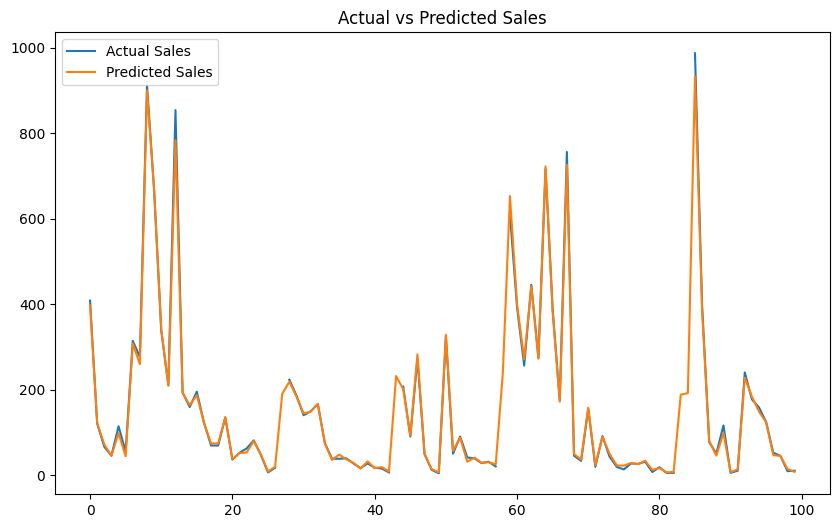

In [ ]:
# Plot Actual vs Predicted

plt.figure(figsize=(10,6))

plt.plot(
    df["sales"].head(100).values,
    label="Actual Sales"
)

plt.plot(
    df["Predicted Sales"].head(100).values,
    label="Predicted Sales"
)

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.show()

In [ ]:
# Forecast Next 10 Sales

future_predictions = df["Predicted Sales"].tail(10)

future_predictions

,Predicted Sales
51280,35.495723
51281,18.285525
51282,26.374575
51283,77.642890
51284,22.604017
51285,11.986178
51286,6.159433
51287,30.819148
51288,11.631466
51289,12.226417


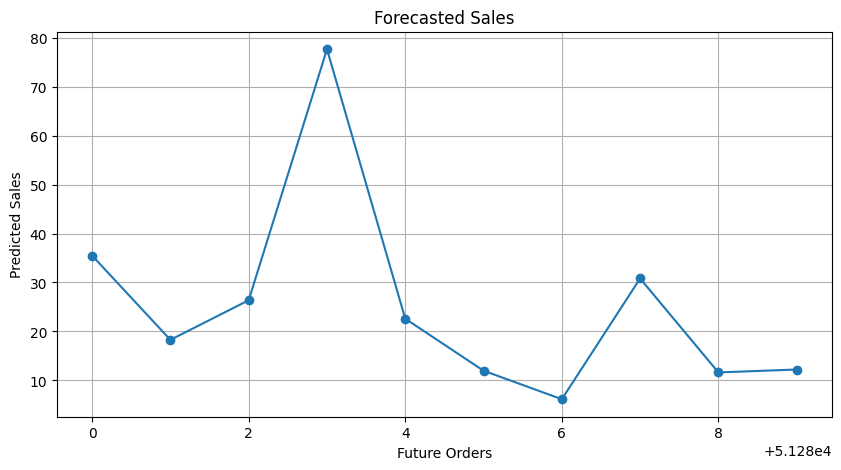

In [ ]:
# Plot Forecast
plt.figure(figsize=(10,5))

future_predictions.plot(marker="o")

plt.title("Forecasted Sales")

plt.xlabel("Future Orders")

plt.ylabel("Predicted Sales")

plt.grid(True)

plt.show()

In [ ]:
# Top 10 Predicted Sales
top_predictions = df.sort_values(

by="Predicted Sales",

ascending=False

)

top_predictions[

["product_name",

"Predicted Sales",

"sales"]

].head(10)

,product_name,Predicted Sales,sales
10066,"Chromcraft Training Table, with Bottom Storage",973.896231,994.0
14710,"Hot File 7-Pocket, Floor Stand",973.736576,999.0
35266,"Hewlett Personal Copier, High-Speed",973.655576,997.0
7967,"Apple Audio Dock, with Caller ID",973.590021,993.0
40661,"Sharp Wireless Fax, Laser",973.590021,993.0
46578,"Rogers Lockers, Single Width",973.376549,988.0
22980,"Rogers Lockers, Blue",973.376549,988.0
43265,"Office Star Rocking Chair, Red",973.376549,986.0
30572,"Dania 3-Shelf Cabinet, Traditional",973.376549,990.0
3455,"Apple Audio Dock, VoIP",971.667243,994.0


In [ ]:
# Business KPIs
print("Total Actual Sales :", df["sales"].sum())

print("Total Predicted Sales :", df["Predicted Sales"].sum())

print("Average Predicted Sales :", df["Predicted Sales"].mean())

print("Maximum Predicted Sale :", df["Predicted Sales"].max())

print("Minimum Predicted Sale :", df["Predicted Sales"].min())

Total Actual Sales : 7835128.0
Total Predicted Sales : 8259768.102132607
Average Predicted Sales : 161.04051671149557
Maximum Predicted Sale : 973.8962305288895
Minimum Predicted Sale : 6.118328378784217


In [ ]:
# Business Recommendations
recommendations = [

"Increase inventory for products with high predicted sales.",

"Focus marketing campaigns on high-performing categories.",

"Offer discounts only where profitability is maintained.",

"Improve logistics for slow delivery regions.",

"Allocate more stock to high-demand markets.",

"Monitor seasonal sales trends for future planning."

]

for i, rec in enumerate(recommendations,1):

    print(f"{i}. {rec}")

1. Increase inventory for products with high predicted sales.
2. Focus marketing campaigns on high-performing categories.
3. Offer discounts only where profitability is maintained.
4. Improve logistics for slow delivery regions.
5. Allocate more stock to high-demand markets.
6. Monitor seasonal sales trends for future planning.


In [ ]:
# Executive Summary
summary = pd.DataFrame({

"Metric":[

"Total Sales",

"Predicted Sales",

"Average Prediction",

"Maximum Prediction",

"Minimum Prediction"

],

"Value":[

df["sales"].sum(),

df["Predicted Sales"].sum(),

df["Predicted Sales"].mean(),

df["Predicted Sales"].max(),

df["Predicted Sales"].min()

]

})

summary

,Metric,Value
0,Total Sales,7.835128e+06
1,Predicted Sales,8.259768e+06
2,Average Prediction,1.610405e+02
3,Maximum Prediction,9.738962e+02
4,Minimum Prediction,6.118328e+00


In [ ]:
# Save Prediction Results
df.to_csv(

"sales_predictions.csv",

index=False

)

print("Prediction file saved.")

Prediction file saved.


In [ ]:
summary.to_csv(

"executive_summary.csv",

index=False

)

summary

,Metric,Value
0,Total Sales,7.835128e+06
1,Predicted Sales,8.259768e+06
2,Average Prediction,1.610405e+02
3,Maximum Prediction,9.738962e+02
4,Minimum Prediction,6.118328e+00


In [ ]:
from google.colab import files

files.download("sales_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("executive_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>